In [10]:
import os
import pandas as pd
from importlib import reload
import numpy as np
import seaborn as sns
from tqdm import *
import scipy.special
from numpy.linalg import eigh
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
plt.style.use('default')  # 防止暗色主题影响图片背景

In [11]:
# ============================================================
# 配置参数（所有需要修改的输入信息全部集中在这里）
# ============================================================

# --- 数据路径 ---
label_path = rf'/root/shared-nvme/lingqiData/trainingdata/V2'
label_name = rf'label'
liquid_path = rf'/root/shared-nvme/lingqiData/trainingdata/V2'
liquid_name = rf'trade_amt'

# --- 回测区间 ---
start = '20230101'
end = '20260331'

# --- 模型路径 ---
root_path = rf'/root/shared-nvme/lingqiData/Model/V2'
model_test_path = rf'{root_path}/model_test/nn--fac20260517--label--dropout0.2'
model_res_path = rf'{root_path}/model_res'

# --- bench 数据路径 ---
bench1_path = rf"/root/shared-nvme/lingqiData/Model/bench/20260515.fea"

# --- 自选股路径 ---
watchlist_path = r'/root/shared-nvme/lingqiData/MyCode.txt'

# --- 机构策略参数 ---
MONEY = 1.5e9             # 资金规模

# --- 个人策略参数 ---
TOP_N = 1                 # 买入股票数量
EXCLUDE_LIMIT_UP = False  # 是否排除涨停板（涨幅>=9.5%）

# --- 预测参数 ---
LABEL_HORIZON_DAYS = 1    # 模型目标对应的持仓天数（label_ret_1d → 1天）
SEASON = '2026q2'         # 预测季度

# --- 数据加载（根据上述路径自动加载，一般无需修改）---
class params:
    liquid_data = pd.read_feather(rf"{liquid_path}/{liquid_name}.fea").set_index("index")
    ret_data = pd.read_feather(rf"{label_path}/{label_name}.fea").set_index("index")

In [12]:
def concat_model_4fold(test_path, res_path):
    market = 'ALL'
    model_res = []
    for fold in range(1, 5):
        # 匹配当前命名规则：目录以 --fold{fold} 结尾
        fold_dirs = [d for d in os.listdir(test_path) if d.endswith(f'--fold{fold}')]
        if len(fold_dirs) == 0:
            print(f"Warning: No directory found for fold{fold} in {test_path}")
            continue
        data_path = rf"{test_path}/{fold_dirs[0]}"
        date_list = list(set([x[:8] for x in os.listdir(data_path)]))
        date_list.sort()
        all_res = []
        for date in date_list:
            date_res = pd.read_pickle(f'{data_path}/{date}.pkl').T
            date_res.index = [date] * len(date_res)
            all_res.append(date_res)
        all_res = pd.concat(all_res, axis=0).sort_index()
        all_res.index.name = "date"
        model_res.append(all_res.apply(lambda x: (x - x.mean()) / x.std(), axis=1))
    model_res = sum(model_res)
    os.makedirs(res_path, exist_ok=True)
    model_res.reset_index().to_feather(rf"{res_path}/{market}_zscore_score.fea")
    return model_res

# 根据模型打分获取对应的label_ret和ic
def get_ret_ic(score, ret_data, liquid_data, start='20230101', end='20241231', money=1.5e9, print_quarterly=False):
    model_score = score.copy()
    label_ret = []
    ic = []
    datelist = []
    # 这是一段日度调仓计算日度收益率的代码
    for date in model_score.loc[start:end].index:
        datelist.append(date)
        code_rank = model_score.loc[date].sort_values(ascending=False)
        ret = ret_data.loc[date].reindex(code_rank.index).fillna(0) * 100
        liquid = liquid_data.loc[date].reindex(code_rank.index).fillna(0)
        total_hold = 0
        total_earned = 0
        for num,code in enumerate(code_rank.index):
            if num >= 500:
                break
            if (money - total_hold) < 1:
                break
            hold_money = min(money - total_hold, liquid[code])
            total_hold += hold_money
            total_earned += ret[code] * hold_money
        total_ret = total_earned / money
        label_ret.append(total_ret)
        ic.append(code_rank.corr(ret))
    ic = pd.Series(ic, index=datelist, dtype='float')
    label_ret = pd.Series(label_ret, index=datelist, dtype='float')
    if print_quarterly:
        print_quarterly_metrics(label_ret, ic)
    return label_ret, ic

def print_quarterly_metrics(ret, ic):
    """打印每个季度的收益和IC指标"""
    ret_series = ret.copy()
    ic_series = ic.copy()
    ret_series.index = pd.to_datetime(ret_series.index)
    ic_series.index = pd.to_datetime(ic_series.index)
    quarterly_ret = ret_series.groupby(pd.Grouper(freq='QE')).mean()
    quarterly_ic = ic_series.groupby(pd.Grouper(freq='QE')).mean()
    quarterly_ret.index = [f"{idx.year}Q{idx.quarter}" for idx in quarterly_ret.index]
    quarterly_ic.index = [f"{idx.year}Q{idx.quarter}" for idx in quarterly_ic.index]
    quarterly_df = pd.DataFrame({
        '季度平均收益': quarterly_ret.round(4),
        '季度平均IC': quarterly_ic.round(4)
    })
    print("\n===== 季度表现指标 =====")
    print(quarterly_df)
    print("=======================\n")

def get_metrics(score, ret_data, liquid_data, start='20230101', end='20261231', money=1.5e9, print_quarterly=True):
    ret_list, ic_list = get_ret_ic(score, ret_data, liquid_data, start=start, end=end, money=money, print_quarterly=print_quarterly)
    # 当前模型评价
    score_metrics = {
        "IC": ic_list.mean(),
        "ICIR": ic_list.mean() / ic_list.std() if ic_list.std() != 0 else 0,
        "top_return": ret_list.mean(),
        "top_return_stability": ret_list.mean() / ret_list.std() if ret_list.std() != 0 else 0
    }
    return score_metrics

def print_metrics(model_metrics, bench_metrics=None, title="模型评估结果"):
    metric_keys = list(model_metrics.keys())
    df = pd.DataFrame(index=metric_keys)
    df.index.name = "指标"
    df["模型值"] = [model_metrics[k] for k in metric_keys]
    if bench_metrics is not None:
        df["基准值"] = [bench_metrics.get(k, None) for k in metric_keys]
        df["提升值"] = ((df["模型值"] - df["基准值"]) / df["基准值"]) * 100
    print(f"\n{title}")
    print(df.round(4))

def plot_model(model_score, bench_score, ret_data, liquid_data, start='20230101', end='20241231', money=1.5e9):
    model_ret, _ = get_ret_ic(model_score, ret_data, liquid_data, start=start, end=end, money=money, print_quarterly=False)
    model_ret = model_ret/100
    bench_ret, _ = get_ret_ic(bench_score, ret_data, liquid_data, start=start, end=end, money=money, print_quarterly=False)
    bench_ret = bench_ret/100

    dates = model_ret.index.tolist()
    seen_months = set()
    month_ticks = []
    month_labels = []
    for i, d in enumerate(dates):
        month = d[:6] 
        if month not in seen_months:
            seen_months.add(month)
            month_ticks.append(i)
            month_labels.append(d)

    # 1. 绘制每日收益率曲线
    plt.figure(figsize=(12, 6))
    plt.plot(dates, model_ret.cumsum(), label='model', color='blue')
    plt.plot(dates, bench_ret.cumsum(), label='bench', color='orange')
    plt.title('Cumulative Return Of Model & Bench', fontsize=14)
    plt.ylabel('Cumulative Return', fontsize=12)
    plt.xticks(ticks=month_ticks, labels=month_labels, rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # 2. 绘制相对提升
    plt.figure(figsize=(12, 6))
    relative_improvement = model_ret - bench_ret
    plt.plot(dates, relative_improvement.cumsum(), label='model', color='blue')
    plt.title('Relative Iprovement', fontsize=14)
    plt.ylabel('Relative Iprovement', fontsize=12)
    plt.xticks(ticks=month_ticks, labels=month_labels, rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

def diversity_entropy(score):
    """
    计算 DE
    """
    if isinstance(score, pd.DataFrame):
        score = score.values
    m = score.shape[1]
    cov_matrix = np.cov(score, rowvar=False)
    eigenvalues, _ = eigh(cov_matrix)
    eigenvalues = np.sort(eigenvalues)[::-1]
    normalized_eigenvalues = eigenvalues / (np.sum(eigenvalues) + 1e-10)
    entropy = 0
    for p in normalized_eigenvalues:
        if p > 1e-10:  # 只对非零概率计算
            entropy -= p * np.log(p)
    de = entropy / np.log(m)
    return de

def ensemble_scores(*dfs):
    """
    输入：任意数量的打分 DataFrame（index=日期，columns=股票）
    输出：拼接后的 DataFrame，columns=score1, score2, ...
    """
    result_list = []
    for i, df in enumerate(dfs, 1):
        df_norm = df.copy()
        df_norm = df_norm.apply(lambda x: (x - x.mean()) / x.std(), axis=1)
        df_norm = df_norm.stack().rename(f"score{i}")
        result_list.append(df_norm)
    result = pd.concat(result_list, axis=1)
    return result.dropna()

def run_individual_strategy(model_score, ret_data, top_n=5, exclude_limit_up=True,
                            limit_up_threshold=0.095, start='20230101', end='20260331'):
    """
    通用个人策略：每天买入打分前 top_n 名的股票，等权配置
    参数:
        model_score: 模型打分 DataFrame (index=日期, columns=股票代码)
        ret_data: 日收益率 DataFrame (index=日期, columns=股票代码), 小数值形式(0.01=1%)
        top_n: 买入股票数量
        exclude_limit_up: 是否排除涨停板 (默认True, 过滤涨幅>=limit_up_threshold的股票)
        limit_up_threshold: 涨停阈值, 默认0.095 (9.5%)
        start, end: 回测区间
    返回:
        (daily_ret_series, stats_dict)
        stats_dict: skip_total(跳过次数), skip_days(有跳过的天数), total_days, skip_day_pct
    """
    model_score_sub = model_score.loc[start:end]
    daily_ret = []
    skip_total = 0
    skip_days = 0
    datelist = []

    for date in model_score_sub.index:
        ranked = model_score_sub.loc[date].sort_values(ascending=False)
        selected = []
        skipped = 0
        for code in ranked.index:
            if len(selected) >= top_n:
                break
            if exclude_limit_up:
                r_val = ret_data.loc[date, code] if code in ret_data.columns else 0.0
                if pd.notna(r_val) and r_val >= limit_up_threshold:
                    skipped += 1
                    continue
            selected.append(code)

        if len(selected) > 0:
            r = ret_data.loc[date, selected].mean()
        else:
            r = 0.0

        datelist.append(date)
        daily_ret.append(r)
        skip_total += skipped
        if skipped > 0:
            skip_days += 1

    daily_ret = pd.Series(daily_ret, index=datelist, dtype='float')
    stats = {
        'skip_total': skip_total,
        'skip_days': skip_days,
        'total_days': len(datelist),
        'skip_day_pct': skip_days / len(datelist) * 100 if len(datelist) > 0 else 0
    }
    return daily_ret, stats

# bench

In [13]:
# 收集模型训练结果
model_score = concat_model_4fold(test_path=model_test_path, res_path=model_res_path)

# 暂时没有bench，四个bench都用自己代替
bench1 = pd.read_feather(bench1_path).set_index("date")
bench2 = model_score.copy()
bench3 = model_score.copy()
bench4 = model_score.copy()

bench_all = ensemble_scores(bench1, bench2, bench3, bench4)
de_series = bench_all.groupby('date').apply(diversity_entropy)
print(f'现有子模型的多样性熵：{de_series.mean()}')
print('各子模型之间的相关性：')
print(bench_all.groupby('date').corr().unstack().mean().unstack())

bench_all = bench_all.mean(axis=1).unstack()
bench_all_metrics = get_metrics(bench_all, params.ret_data, params.liquid_data, start=start, end=end, money=MONEY, print_quarterly=True)
print_metrics(bench_all_metrics)

现有子模型的多样性熵：0.15035762749587256
各子模型之间的相关性：
          score1    score2    score3    score4
score1  1.000000  0.847271  0.847271  0.847271
score2  0.847271  1.000000  1.000000  1.000000
score3  0.847271  1.000000  1.000000  1.000000
score4  0.847271  1.000000  1.000000  1.000000

===== 季度表现指标 =====
        季度平均收益  季度平均IC
2024Q1  0.2154  0.0621
2024Q2 -0.2895  0.0353
2024Q3  0.6321  0.0555
2024Q4  0.2842  0.0499
2025Q1  0.0030  0.0394
2025Q2  0.6951  0.0533
2025Q3  0.4588  0.0344
2025Q4  0.4670  0.0370
2026Q1  0.0367  0.0339


模型评估结果
                         模型值
指标                          
IC                    0.0446
ICIR                  0.3461
top_return            0.2873
top_return_stability  0.0915


# 使用示例

---单一模型评估---

===== 季度表现指标 =====
        季度平均收益  季度平均IC
2024Q1  0.2538  0.0601
2024Q2 -0.4065  0.0340
2024Q3  0.4420  0.0541
2024Q4  0.5061  0.0491
2025Q1 -0.0975  0.0354
2025Q2  0.6068  0.0514
2025Q3  0.4673  0.0336
2025Q4  0.5158  0.0353
2026Q1 -0.0250  0.0327


模型评估结果
                         模型值
指标                          
IC                    0.0429
ICIR                  0.3381
top_return            0.2609
top_return_stability  0.0832
---该模型与现有集成模型的相关性---
0.9911
---模型集成评估---
加入当前模型后的多样性熵：0.11386777936571768
当前模型与现有子模型之间的相关性：
          score1    score2    score3    score4    score5
score1  1.000000  0.847271  0.847271  0.847271  0.847271
score2  0.847271  1.000000  1.000000  1.000000  1.000000
score3  0.847271  1.000000  1.000000  1.000000  1.000000
score4  0.847271  1.000000  1.000000  1.000000  1.000000
score5  0.847271  1.000000  1.000000  1.000000  1.000000

===== 季度表现指标 =====
        季度平均收益  季度平均IC
2024Q1  0.1952  0.0617
2024Q2 -0.3141  0.0351
2024Q3  0.5656  0.0553
2024Q4  

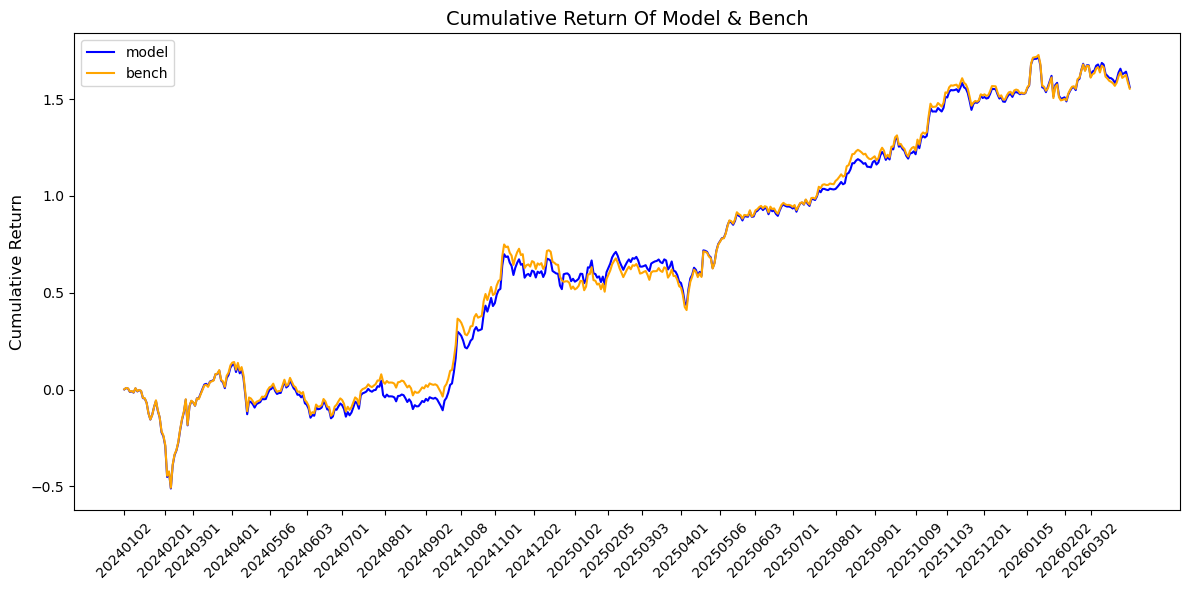

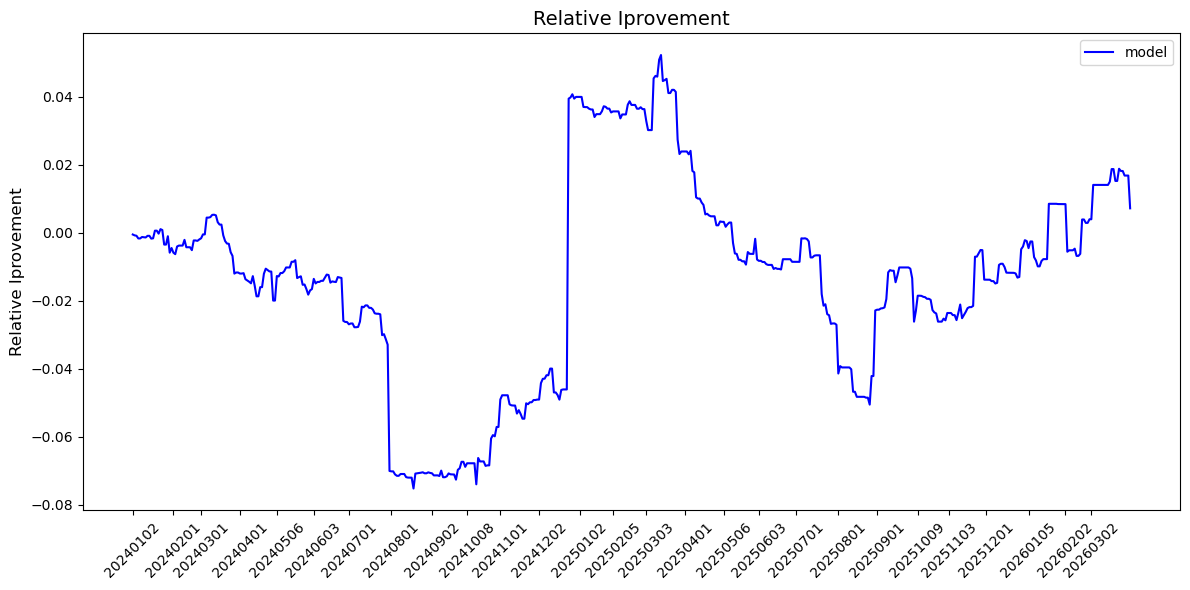

In [14]:
# 单模型效果评估（完整季度输出）
# 注意：当前 bench = 模型自身，集成评估无实际意义，待有真实 bench 后替换 bench1~4 即可
print("---单一模型评估---")
score1_metrics = get_metrics(model_score, params.ret_data, params.liquid_data, start=start, end=end, money=MONEY, print_quarterly=True)
print_metrics(score1_metrics)

# TODO: 有真实bench后，取消下面注释并替换 bench1~4
print("---该模型与现有集成模型的相关性---")
corr_with_bench = model_score.reindex(columns=bench_all.columns, index=bench_all.index).corrwith(bench_all, axis=1)
print(f"{corr_with_bench.mean():.4f}")

print("---模型集成评估---")
bench_new = ensemble_scores(bench1, bench2, bench3, bench4, model_score)
print(f'加入当前模型后的多样性熵：{bench_new.groupby("date").apply(diversity_entropy).mean()}')
print('当前模型与现有子模型之间的相关性：')
print(bench_new.groupby('date').corr().unstack().mean().unstack())
bench_new_metrics = get_metrics(bench_new.mean(axis=1).unstack(), params.ret_data, params.liquid_data, start=start, end=end, money=MONEY, print_quarterly=True)
print_metrics(bench_new_metrics, bench_all_metrics)
plot_model(bench_new.mean(axis=1).unstack(), bench_all, params.ret_data, params.liquid_data, start=start, end=end, money=MONEY)

# 通用个人策略 vs Top 500 机构策略
# 自定义买入数量 + 涨停板过滤（涨幅>=9.5%不能买入）
# 使用 run_individual_strategy() 函数，修改 TOP_N 和 EXCLUDE_LIMIT_UP 即可


===== 多策略对比 =====
策略                                      年化收益     夏普比率       季均收益
-----------------------------------------------------------------
Top 500 (机构, 流动性约束)                    65.74%   1.3206     0.2514%
Top 1 (个人, 不过滤涨停)                     332.42%   1.6503     1.2984%
Top 3 (个人, 不过滤涨停)                     183.08%   2.2321     0.7197%
Top 5 (个人, 不过滤涨停)                     158.10%   2.5206     0.6196%
Top 10 (个人, 不过滤涨停)                    128.80%   2.7041     0.5049%
Top 20 (个人, 不过滤涨停)                     95.25%   2.3684     0.3723%


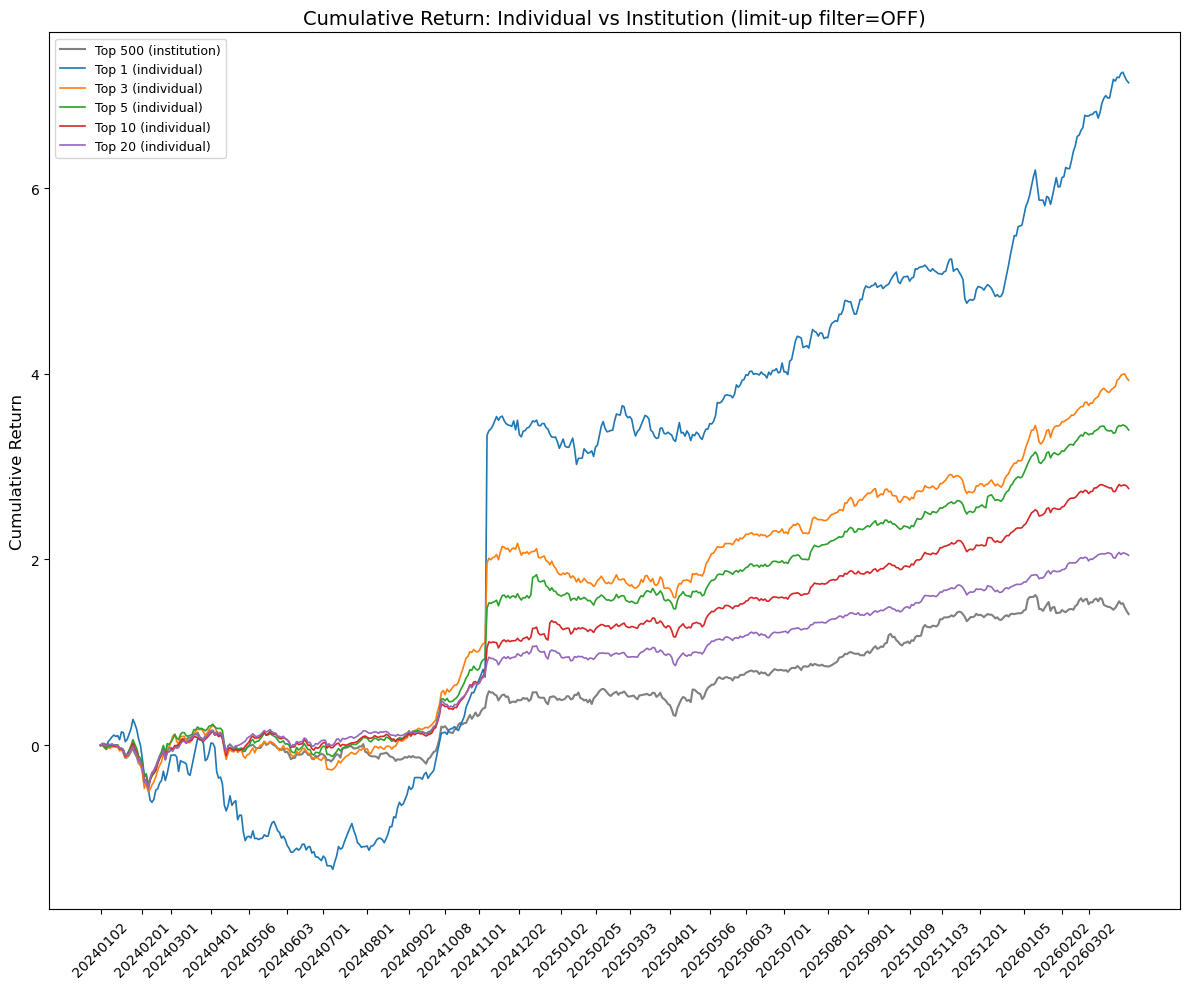

In [15]:
# ============================================================
# 通用个人策略：自定义买入数量 + 涨停板过滤
# 用法：修改顶部配置区的 TOP_N 和 EXCLUDE_LIMIT_UP，然后运行本单元格
# ============================================================

# Top 500 机构策略（用于对比）
top500_ret, _ = get_ret_ic(model_score, params.ret_data, params.liquid_data, start=start, end=end, money=MONEY, print_quarterly=False)
top500_ret = top500_ret / 100

# ---- 辅助函数 ----
def _print_strategy(label, ret_series):
    ann = ret_series.mean() * 252 * 100
    sharpe = ret_series.mean() / ret_series.std() * np.sqrt(252) if ret_series.std() > 0 else 0
    q_avg = ret_series.groupby(pd.to_datetime(ret_series.index).to_period('Q')).mean().mean() * 100
    print(f"{label:<35} {ann:>8.2f}% {sharpe:>8.4f} {q_avg:>10.4f}%")

# ---- 多策略对比 ----
print("\n===== 多策略对比 =====")
print(f"{'策略':<35} {'年化收益':>8} {'夏普比率':>8} {'季均收益':>10}")
print("-" * 65)
_print_strategy("Top 500 (机构, 流动性约束)", top500_ret)

for n in [1, 3, 5, 10, 20]:
    r, s = run_individual_strategy(model_score, params.ret_data, top_n=n,
                                   exclude_limit_up=EXCLUDE_LIMIT_UP, start=start, end=end)
    _print_strategy(f"Top {n} (个人, 不过滤涨停)", r)



# ---- 绘图对比 ----
dates = top500_ret.index.tolist()
seen_months = set()
month_ticks, month_labels = [], []
for i, d in enumerate(dates):
    month = d[:6]
    if month not in seen_months:
        seen_months.add(month)
        month_ticks.append(i)
        month_labels.append(d)

fig, axes = plt.subplots(1, 1, figsize=(12, 10))

# 图1: 多策略累计收益对比
axes.plot(dates, top500_ret.cumsum(), label='Top 500 (institution)', color='gray', linewidth=1.5)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
for i, n in enumerate([1, 3, 5, 10, 20]):
    r, _ = run_individual_strategy(model_score, params.ret_data, top_n=n,
                                   exclude_limit_up=EXCLUDE_LIMIT_UP, start=start, end=end)
    axes.plot(dates, r.cumsum(), label=f'Top {n} (individual)', color=colors[i], linewidth=1.2)
axes.set_title(f'Cumulative Return: Individual vs Institution (limit-up filter={"ON" if EXCLUDE_LIMIT_UP else "OFF"})', fontsize=14)
axes.set_ylabel('Cumulative Return', fontsize=12)
axes.set_xticks(month_ticks)
axes.set_xticklabels(month_labels, rotation=45)
axes.legend(fontsize=9)

plt.tight_layout()
plt.show()

# 预测补充 & 最新推荐
自动检测 factor 数据中超出 model_res 覆盖范围的日期，使用最优模型进行预测，并展示最新打分结果与投资建议。

In [16]:
# ============================================================
# 1. 自动预测：补充 model_res 未覆盖的最新日期
# ============================================================
import sys
sys.path.insert(0, r'/root/shared-nvme/lingqiData/Model/V2')
from prediction import predict_missing_dates

new_scores = predict_missing_dates(
    model_score,
    season=SEASON
)

if new_scores is not None:
    model_score_extended = pd.concat([model_score, new_scores], axis=0).sort_index()
    print(f"合并完成：原始 {len(model_score)} 天 + 新增 {len(new_scores)} 天 = {len(model_score_extended)} 天")
    print(f"新增日期: {list(new_scores.index)}")
else:
    model_score_extended = model_score.copy()
    print("无新增日期，使用原始 model_score。")

[预测] 发现 2 个未覆盖日期: ['20260514', '20260515']
[预测] 使用 4 个 fold 进行预测
[预测]   [fold1] epoch=12-val_wei=0.4110.ckpt (val_wei=0.4110)
[预测]   [fold2] epoch=5-val_wei=0.5532.ckpt (val_wei=0.5532)
[预测]   [fold3] epoch=55-val_wei=0.9790.ckpt (val_wei=0.9790)
[预测]   [fold4] epoch=27-val_wei=1.3644.ckpt (val_wei=1.3644)
[预测]   [20260514] 完成, 2542 只股票
[预测]   [20260515] 完成, 2542 只股票
[预测] 完成，新增 2 天数据。
合并完成：原始 568 天 + 新增 2 天 = 570 天
新增日期: ['20260514', '20260515']


In [17]:
# ============================================================
# 2. 最新推荐展示：股票名称映射、Top 打分、投资建议
# ============================================================

# --- 股票代码 → 名称映射 ---
import re
stock_info = pd.read_parquet('/root/shared-nvme/lingqiData/data/list.parquet')
stock_info = stock_info[stock_info['list_status'] == 'L']
code_to_name = {
    re.sub(r'\.(SZ|SH|BJ)$', '', row['stock_code']): row['name']
    for _, row in stock_info.iterrows()
}

# --- 交易日历 ---
cal = pd.read_parquet('/root/shared-nvme/lingqiData/data/calendar.parquet')
cal = cal[cal['is_open'] == 1]
_trade_dates = sorted(cal['date'].astype(str).str.replace('-', '').tolist())

def get_nth_next_trade_date(date_str, n=1):
    """获取 date_str 之后第 n 个交易日"""
    try:
        idx = _trade_dates.index(date_str)
        if idx + n < len(_trade_dates):
            return _trade_dates[idx + n]
    except (ValueError, IndexError):
        pass
    return None

def fmt_date(date_str):
    if date_str is None:
        return "待定（交易日历未覆盖）"
    return f"{date_str[:4]}年{int(date_str[4:6])}月{int(date_str[6:8])}日"

# ============================================================
# 数据当前日期 & 预测日期推算
# ============================================================

# 原始 model_res 的最新日期（有真实 label 的最后一天）
last_label_date = model_score.index.max()

# 因子数据的最新日期（即这一批数据的"当前日期"）
latest_factor_date = model_score_extended.index.max()

# 本次新增的预测日期（model_res 未覆盖、通过 prediction 补充的日期）
predicted_dates = sorted(set(model_score_extended.index) - set(model_score.index))
predicted_dates.sort()


# ============================================================
# 展示预测日期的 Top 推荐
# ============================================================
print()
print("=" * 72)
print("                    最新模型打分 Top 推荐")
print("=" * 72)

for date in predicted_dates:
    scores = model_score_extended.loc[date].sort_values(ascending=False)
    buy_date = get_nth_next_trade_date(date, 1)       # 买入日 = 下一个交易日
    sell_date = get_nth_next_trade_date(buy_date, LABEL_HORIZON_DAYS) if buy_date else None  # 卖出日 = 买入后第N个交易日
    
    print(f"\n{'─' * 60}")
    print(f"  当前日期：{fmt_date(latest_factor_date)} 收盘")
    if buy_date and sell_date:
        print(f"  模型预测{LABEL_HORIZON_DAYS}日收益率：{fmt_date(buy_date)} 买入 → {fmt_date(sell_date)} 卖出")
    elif buy_date:
        print(f"  模型预测{LABEL_HORIZON_DAYS}日收益率：{fmt_date(buy_date)} 买入 → {fmt_date(sell_date)}")
    else:
        print(f"  模型预测{LABEL_HORIZON_DAYS}日收益率：无法推算交易日（需更新交易日历）")
    print(f"{'─' * 60}")
    
    top_n = min(10, len(scores))
    print(f"\n  {'排名':<5}{'代码':<10}{'名称':<12}{'打分':>10}")
    print(f"  {'-' * 37}")
    for rank, (code, score) in enumerate(scores.head(top_n).items(), 1):
        name = code_to_name.get(code, '未知')
        sign = '+' if score > 0 else ''
        print(f"  {rank:<5}{code:<10}{name:<12}{sign}{score:>9.4f}")


                    最新模型打分 Top 推荐

────────────────────────────────────────────────────────────
  当前日期：2026年5月15日 收盘
  模型预测1日收益率：2026年5月15日 买入 → 待定（交易日历未覆盖）
────────────────────────────────────────────────────────────

  排名   代码        名称                  打分
  -------------------------------------
  1    000539    粤电力Ａ        +  10.3939
  2    002335    科华数据        +  10.0563
  3    002647    *ST仁东       +   9.1123
  4    600979    广安爱众        +   9.0112
  5    002638    勤上股份        +   8.9822
  6    002156    通富微电        +   8.3980
  7    000066    中国长城        +   8.1981
  8    603399    永杉锂业        +   8.1573
  9    603601    再升科技        +   8.0521
  10   002217    合力泰         +   7.9443

────────────────────────────────────────────────────────────
  当前日期：2026年5月15日 收盘
  模型预测1日收益率：无法推算交易日（需更新交易日历）
────────────────────────────────────────────────────────────

  排名   代码        名称                  打分
  -------------------------------------
  1    600330    天通股份        +  11.9054
  2   

# 自选股排序
从 `/root/shared-nvme/lingqiData/MyCode.txt` 读取自选股列表，展示全部自选股在最新预测日期上的打分排名。

In [18]:
# ============================================================
# 自选股排序：读取 MyCode.txt，展示全部自选股打分
# ============================================================

watchlist = np.loadtxt(watchlist_path)
watchlist_codes = [str(int(code)).zfill(6) for code in watchlist]

for date in predicted_dates:
    scores = model_score_extended.loc[date]
    buy_date = get_nth_next_trade_date(date, 1)
    sell_date = get_nth_next_trade_date(buy_date, LABEL_HORIZON_DAYS) if buy_date else None

    # 筛选出自选股并排序
    watch_scores = scores.reindex(watchlist_codes).dropna().sort_values(ascending=False)
    missing = [c for c in watchlist_codes if c not in scores.index]

    print(f"\n{'─' * 60}")
    print(f"  自选股打分排序")
    print(f"  当前日期：{fmt_date(latest_factor_date)} 收盘")
    if buy_date and sell_date:
        print(f"  模型预测{LABEL_HORIZON_DAYS}日收益率：{fmt_date(buy_date)} 买入 → {fmt_date(sell_date)} 卖出")
    elif buy_date:
        print(f"  模型预测{LABEL_HORIZON_DAYS}日收益率：{fmt_date(buy_date)} 买入 → {fmt_date(sell_date)}")
    else:
        print(f"  模型预测{LABEL_HORIZON_DAYS}日收益率：无法推算交易日（需更新交易日历）")
    print(f"{'─' * 60}")

    print(f"\n  {'排名':<5}{'代码':<10}{'名称':<12}{'打分':>10}")
    print(f"  {'-' * 37}")
    for rank, (code, score) in enumerate(watch_scores.items(), 1):
        name = code_to_name.get(code, '未知')
        sign = '+' if score > 0 else ''
        print(f"  {rank:<5}{code:<10}{name:<12}{sign}{score:>9.4f}")

    if missing:
        print(f"\n  以下自选股无模型打分（可能已退市或不在股票池中）：{missing}")


────────────────────────────────────────────────────────────
  自选股打分排序
  当前日期：2026年5月15日 收盘
  模型预测1日收益率：2026年5月15日 买入 → 待定（交易日历未覆盖）
────────────────────────────────────────────────────────────

  排名   代码        名称                  打分
  -------------------------------------
  1    002466    天齐锂业        +   7.1497
  2    601988    中国银行        +   3.0838
  3    000725    京东方Ａ        +   0.9866
  4    601398    工商银行        +   0.7877
  5    601857    中国石油        +   0.7541
  6    600030    中信证券        +   0.6795
  7    601288    农业银行        +   0.3008
  8    000100    TCL科技         -0.0885
  9    601919    中远海控          -0.4891
  10   601899    紫金矿业          -0.6196
  11   002594    比亚迪           -1.3431
  12   002230    科大讯飞          -1.4568
  13   601360    三六零           -1.4986
  14   000625    长安汽车          -1.7235
  15   601933    永辉超市          -1.8303
  16   601888    中国中免          -2.0516
  17   000651    格力电器          -2.5153
  18   601138    工业富联          -2.5298
  19   000858   

# 个股分数查询
输入日期和股票代码，查询该股票在当天的模型打分、全市场排名及百分位。

In [ ]:
# ============================================================
# 个股分数查询：输入日期 + 股票代码，查询打分、排名、百分位
# 用法：修改 query_date 和 query_code，然后运行本单元格
# ============================================================

query_date = '20260515'   # <-- 修改为你要查询的日期 (YYYYMMDD)
query_code = '002466'     # <-- 修改为你要查询的股票代码 (6位数字)

scores_all = model_score_extended
code_name = code_to_name.get(query_code, '未知')

# --- 检查日期 ---
if query_date not in scores_all.index:
    avail = sorted(scores_all.index)
    print(f"日期 {query_date} 不在打分数据中。")
    print(f"可用日期范围：{avail[0]} ~ {avail[-1]}，共 {len(avail)} 个交易日。")
else:
    date_scores = scores_all.loc[query_date].dropna().sort_values(ascending=False)
    total = len(date_scores)

    # --- 检查股票 ---
    if query_code not in date_scores.index:
        print(f"股票 {query_code}（{code_name}）在 {fmt_date(query_date)} 无打分数据（可能停牌/退市/未覆盖）。")
    else:
        score = date_scores[query_code]
        rank = date_scores.index.get_loc(query_code) + 1
        pct = rank / total * 100

        print(f"\n{'=' * 56}")
        print(f"  个股分数查询")
        print(f"{'=' * 56}")
        print(f"  日期      ：{fmt_date(query_date)}")
        print(f"  代码 / 名称：{query_code} / {code_name}")
        print(f"  模型打分  ：{score:+.4f}")
        print(f"  排名      ：{rank} / {total}")
        print(f"  百分位    ：Top {pct:.2f}%")
        print(f"{'=' * 56}")

        # --- 附近排名参考 ---
        margin = 3
        nearby = date_scores.iloc[max(0, rank - 1 - margin):min(total, rank + margin)]
        print(f"\n  附近排名参考：")
        print(f"  {'排名':<5}{'代码':<10}{'名称':<12}{'打分':>10}")
        print(f"  {'─' * 37}")
        for (c, s) in nearby.items():
            marker = '→' if c == query_code else ' '
            n = code_to_name.get(c, '未知')
            sign = '+' if s > 0 else ''
            print(f"  {marker} {date_scores.index.get_loc(c) + 1:<3}{c:<10}{n:<12}{sign}{s:>9.4f}")